
RAW DATA:
         Date       Category Amount Payment_Mode
0  2025-01-01           Food    450          UPI
1  2025-01-02         Travel    abc         Cash
2  2025-01-03       Shopping   1200         Card
3  2025-01-04          Bills    NaN          UPI
4  2025-01-05  Entertainment    500          UPI

MISSING VALUES AFTER CLEANING:
Date            0
Category        0
Amount          3
Payment_Mode    0
dtype: int64

CLEANED DATA SAMPLE:
        Date       Category  Amount Payment_Mode  Month  Year   Day_Name  \
0 2025-01-01           Food   450.0          UPI      1  2025  Wednesday   
1 2025-01-02         Travel     NaN         Cash      1  2025   Thursday   
2 2025-01-03       Shopping  1200.0         Card      1  2025     Friday   
3 2025-01-04          Bills     NaN          UPI      1  2025   Saturday   
4 2025-01-05  Entertainment   500.0          UPI      1  2025     Sunday   

   Is_Weekend     Week  
0       False  2025-00  
1       False  2025-00  
2       False  2025-00  

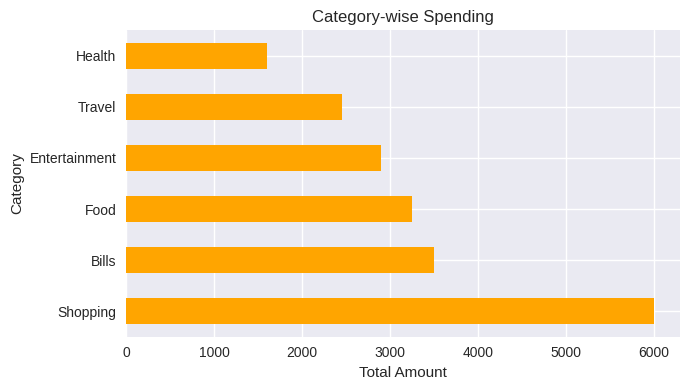

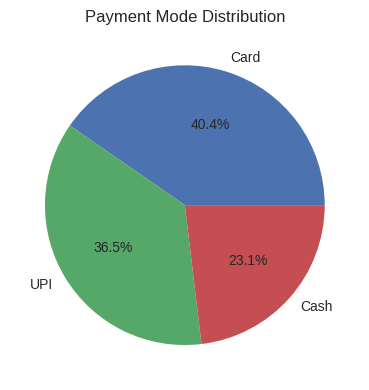

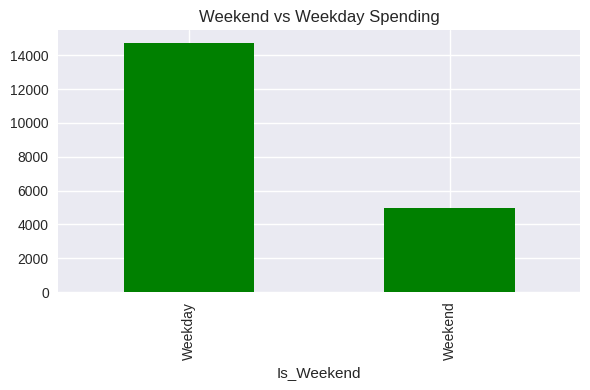

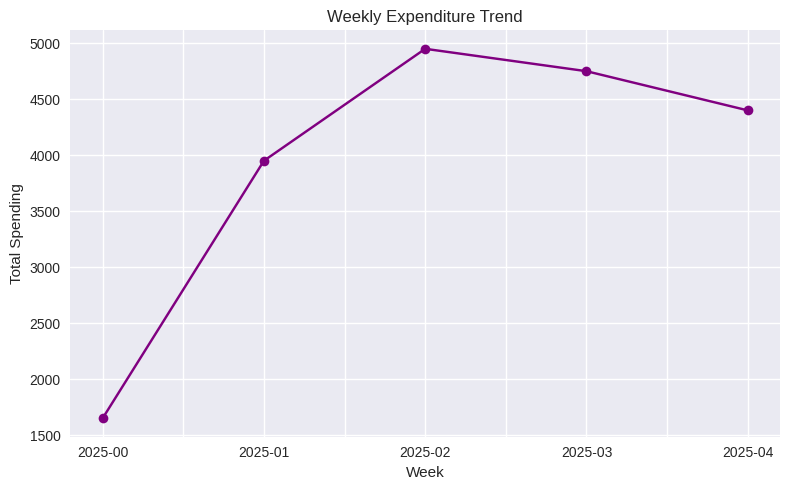


BUSINESS INSIGHTS
Total Transactions: 31
Valid Amount Entries: 28
Missing Amount %: 9.68%

Total Spending: 19700.00
Average Spending: 703.57
Top Category: Shopping
Lowest Category: Health
Most Used Payment Mode: Card

Category Contribution (%):
Category
Shopping         30.456853
Bills            17.766497
Food             16.497462
Entertainment    14.720812
Travel           12.436548
Health            8.121827
Name: Amount, dtype: float64

Monthly analysis skipped (single-month dataset)

Project Completed Successfully


In [2]:
# ==========================================
# EXPENSE DATA CLEANING & ANALYSIS PROJECT
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

# ==========================================
# STEP 1: LOAD DATASET
# ==========================================

df = pd.read_csv("expenses_dirty.csv")

print("\nRAW DATA:")
print(df.head())

# ==========================================
# STEP 2: DATA CLEANING
# ==========================================

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

# Remove negative values
df["Amount"] = df["Amount"].mask(df["Amount"] < 0, np.nan)

# Clean text fields (handle empty + whitespace)
df["Category"] = df["Category"].replace(r"^\s*$", np.nan, regex=True)
df["Payment_Mode"] = df["Payment_Mode"].replace(r"^\s*$", np.nan, regex=True)

# ==========================================
# STEP 3: NULL CHECK
# ==========================================

print("\nMISSING VALUES AFTER CLEANING:")
print(df.isnull().sum())

# ==========================================
# STEP 4: FEATURE ENGINEERING
# ==========================================

df = df.dropna(subset=["Date"])

df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df["Day_Name"] = df["Date"].dt.day_name()
df["Is_Weekend"] = df["Date"].dt.weekday >= 5
df["Week"] = df["Date"].dt.strftime("%Y-%U")

print("\nCLEANED DATA SAMPLE:")
print(df.head())

# ==========================================
# STEP 5: ANALYSIS
# ==========================================

total_spend = df["Amount"].sum(skipna=True)
avg_spend = df["Amount"].mean(skipna=True)

category_spend = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
payment_spend = df.groupby("Payment_Mode")["Amount"].sum().sort_values(ascending=False)
weekly_spend = df.groupby("Week")["Amount"].sum()
weekend_spend = df.groupby("Is_Weekend")["Amount"].sum()

category_percent = (category_spend / category_spend.sum()) * 100

# Safe monthly handling (NO NoneType issues)
if df["Month"].nunique() > 1:
    monthly_spend = df.groupby("Month")["Amount"].sum().sort_index()
else:
    monthly_spend = None

# ==========================================
# STEP 6: VISUALIZATION
# ==========================================

# Category-wise spending
plt.figure(figsize=(7,4))
category_spend.plot(kind="barh", color="orange")
plt.title("Category-wise Spending")
plt.xlabel("Total Amount")
plt.tight_layout()
plt.show()

# Payment mode distribution
plt.figure(figsize=(6,4))
payment_spend.plot(kind="pie", autopct="%1.1f%%")
plt.title("Payment Mode Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Weekend vs Weekday
plt.figure(figsize=(6,4))
weekend_spend.plot(kind="bar", color="green")
plt.xticks([0,1], ["Weekday","Weekend"])
plt.title("Weekend vs Weekday Spending")
plt.tight_layout()
plt.show()

# Weekly trend
plt.figure(figsize=(8,5))
weekly_spend.plot(kind="line", marker="o", color="purple")
plt.title("Weekly Expenditure Trend")
plt.xlabel("Week")
plt.ylabel("Total Spending")
plt.grid(True)
plt.tight_layout()
plt.show()

# Monthly trend (only if applicable)
if monthly_spend is not None:
    plt.figure(figsize=(6,4))
    monthly_spend.plot(kind="bar", color="skyblue")
    plt.title("Monthly Spending Trend")
    plt.xlabel("Month")
    plt.ylabel("Total Spending")
    plt.tight_layout()
    plt.show()

# ==========================================
# STEP 7: INSIGHTS
# ==========================================

print("\n==============================")
print("BUSINESS INSIGHTS")
print("==============================")

print(f"Total Transactions: {len(df)}")
print(f"Valid Amount Entries: {df['Amount'].notna().sum()}")
print(f"Missing Amount %: {df['Amount'].isna().mean() * 100:.2f}%")

print(f"\nTotal Spending: {total_spend:.2f}")
print(f"Average Spending: {avg_spend:.2f}")

if not category_spend.dropna().empty:
    print(f"Top Category: {category_spend.idxmax()}")
    print(f"Lowest Category: {category_spend.idxmin()}")

if not payment_spend.dropna().empty:
    print(f"Most Used Payment Mode: {payment_spend.idxmax()}")

print("\nCategory Contribution (%):")
print(category_percent.sort_values(ascending=False))

# Safe monthly insights
if monthly_spend is not None and len(monthly_spend) > 0:
    print(f"\nHighest Spending Month: {monthly_spend.idxmax()}")
    print(f"Lowest Spending Month: {monthly_spend.idxmin()}")
else:
    print("\nMonthly analysis skipped (single-month dataset)")

print("\nProject Completed Successfully")